# ChatGPT API few-shot grading benchmark

This notebook evaluates the OpenAI ChatGPT API on every row of `training_data_moh_eng_fewshot_v2.csv` using the same scored-example few-shot method as the QLoRA notebook. It preserves the full-dataset run, resumable checkpoints, final-score metrics, and comparison reports used by the rubric-based benchmark.

The API key is read from a local `.env` file and is never displayed. Set `OPENAI_API_KEY`; the model can be overridden with `OPENAI_MODEL`. Synchronous Chat Completions requests are made one example at a time, and completed results are reused when the notebook is restarted.

## 1. Install inference and analysis dependencies



In [16]:
%pip install -U openai httpx zstandard

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: openai in c:\Users\ngjac\anaconda3\Lib\site-packages (3.24.0)




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and experiment configuration

This section loads the OpenAI client and reads its API key from `.env`. No local model weights or GPU are required.

In [17]:
import ast
import csv
import json
import math
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from openai import OpenAI
from sklearn.metrics import cohen_kappa_score
from tqdm.auto import tqdm


def read_env_value(path, key):
    """Read one key from a local dotenv-style file without displaying secrets."""
    if not path.exists():
        raise FileNotFoundError(f"Missing environment file: {path.resolve()}")
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        name, value = line.split("=", 1)
        name = name.strip().removeprefix("export ").strip()
        if name != key:
            continue
        value = value.strip()
        if len(value) >= 2 and value[0] == value[-1] and value[0] in ("'", '"'):
            value = value[1:-1]
        return value
    return None


ENV_PATH = Path("./.env")
OPENAI_API_KEY = read_env_value(ENV_PATH, "OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Missing or empty OPENAI_API_KEY in .env")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-5.6-luna")
OPENAI_CLIENT = OpenAI(api_key=OPENAI_API_KEY)

DATASET_PATH = Path("../Datasets/training_data_moh_eng_fewshot_v2.csv")
RESULTS_DIR = Path("./fewshot_model_results_gpt")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "openai_gpt56_luna_fewshot_v1"
OVERWRITE_EXISTING = False
THINKING_MODES = [False]
MAX_NEW_TOKENS = {False: 2048, True: 2048}

MODEL_SPECS = [
    {"name": "ChatGPT (few-shot)", "model_id": OPENAI_MODEL, "provider": "openai", "batch_size": 1},
]

print("ChatGPT few-shot API client configured.")
print("Model:", OPENAI_MODEL)
print("Dataset:", DATASET_PATH)
print("Modes per model:", len(THINKING_MODES))

ChatGPT few-shot API client configured.
Model: gpt-5.6-luna
Dataset: ..\Datasets\training_data_moh_eng_fewshot_v2.csv
Modes per model: 1


In [18]:
import httpx


# Force a response encoding that avoids the incompatible zstd decoder path.
OPENAI_HTTP_CLIENT = httpx.Client(
    headers={"Accept-Encoding": "gzip, deflate, identity"},
)
OPENAI_CLIENT = OpenAI(
    api_key=OPENAI_API_KEY,
    default_headers={"Accept-Encoding": "gzip, deflate, identity"},
    http_client=OPENAI_HTTP_CLIENT,
)

print("OpenAI client configured with zstd disabled.")

OpenAI client configured with zstd disabled.


## 3. Load and validate the full few-shot dataset

This benchmark uses every valid row in the few-shot dataset. No train/validation/test split is made, and no rubric criteria are required because the few-shot method predicts the recorded scalar score directly.

The dataset must contain the question, desired answer, student answer, maximum score, recorded student score, and one example answer for every possible score.

In [19]:
EXAMPLE_RE = re.compile(r"^Score\s+(\d+)\s*/\s*(\d+):\s*(.+)$", re.DOTALL)


def parse_int(value, column_name, minimum=0, maximum=None):
    try:
        number = float(value)
    except (TypeError, ValueError) as error:
        raise ValueError(f"{column_name} must be numeric: {value!r}") from error
    if not math.isfinite(number) or not number.is_integer():
        raise ValueError(f"{column_name} must be a whole number: {value!r}")
    result = int(number)
    if result < minimum or (maximum is not None and result > maximum):
        raise ValueError(f"{column_name} must be between {minimum} and {maximum}: {value!r}")
    return result


def parse_examples(value, max_score):
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        try:
            items = json.loads(value)
        except json.JSONDecodeError as error:
            raise ValueError(f"examples is not valid JSON: {value[:100]!r}") from error
    else:
        raise TypeError(f"examples must be a JSON array string, got {type(value).__name__}.")

    if not isinstance(items, list) or len(items) != max_score + 1:
        raise ValueError(f"Expected {max_score + 1} examples for max_score={max_score}.")

    parsed = []
    for item in items:
        match = EXAMPLE_RE.match(str(item).strip())
        if not match:
            raise ValueError(f"Example not in 'Score X/Y: answer' format: {item!r}")
        score, out_of, answer = int(match.group(1)), int(match.group(2)), match.group(3).strip()
        if out_of != max_score or not 0 <= score <= max_score or not answer:
            raise ValueError(f"Invalid example score or answer: {item!r}")
        parsed.append((score, answer))

    scores = sorted(score for score, _ in parsed)
    if scores != list(range(max_score + 1)):
        raise ValueError(f"Examples must cover every score from 0 to {max_score}: {scores}")
    return sorted(parsed, key=lambda item: -item[0])


df = pd.read_csv(DATASET_PATH, keep_default_na=False).reset_index(drop=True)
required_columns = [
    "question", "desired_answer", "student_answer", "max_score", "student_score", "examples",
]
missing = [column for column in required_columns if column not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

records = []
validation_errors = []
for index, row in df.iterrows():
    try:
        question = str(row["question"]).strip()
        desired_answer = str(row["desired_answer"]).strip()
        max_score = parse_int(row["max_score"], "max_score", minimum=1)
        student_score = parse_int(row["student_score"], "student_score", minimum=0, maximum=max_score)
        examples = parse_examples(row["examples"], max_score)
        if not question or not desired_answer:
            raise ValueError("question and desired_answer must be nonempty")
        records.append({
            "dataset_index": int(index),
            "id": str(row["id"]) if "id" in row else str(index),
            "question": question,
            "desired_answer": desired_answer,
            "student_answer": str(row["student_answer"]),
            "max_score": max_score,
            "student_score": student_score,
            "examples": examples,
        })
    except (KeyError, TypeError, ValueError) as error:
        validation_errors.append(f"row {index}: {error}")

if validation_errors:
    raise ValueError("Dataset validation failed:\n" + "\n".join(validation_errors[:20]))

df = pd.DataFrame(records)
print("Full dataset rows:", len(df))
print("Maximum score distribution:", df["max_score"].value_counts().sort_index().to_dict())
display(df[["question", "student_answer", "max_score", "student_score", "examples"]].head())

Full dataset rows: 3778
Maximum score distribution: {1: 971, 2: 1212, 3: 813, 4: 450, 5: 332}


,question,student_answer,max_score,student_score,examples
0,What is the role of a prototype program in pro...,High risk problems are address in the prototyp...,1,0,"[(1, A prototype is a stripped-down program th..."
1,What is the role of a prototype program in pro...,To simulate portions of the desired final prod...,1,1,"[(1, A prototype is a stripped-down program th..."
2,What is the role of a prototype program in pro...,A prototype program simulates the behaviors of...,1,1,"[(1, A prototype is a stripped-down program th..."
3,What is the role of a prototype program in pro...,Defined in the Specification phase a prototype...,1,1,"[(1, A prototype is a stripped-down program th..."
4,What is the role of a prototype program in pro...,It is used to let the users have a first idea ...,1,0,"[(1, A prototype is a stripped-down program th..."


## 4. Shared few-shot grading prompt and strict output parser

The model sees the question, reference answer, student answer, and one scored example for every possible score. The final answer must be one JSON object containing only an integer `score`.

In [20]:
SYSTEM_PROMPT = (
    "You are a strict, consistent grader of short answers to computer science exam questions.\n\n"
    "Compare the student answer with the reference answer and the scored examples. "
    "Use the examples to calibrate how much partial credit each score represents.\n"
    "Accept different wording, synonyms, and correct code snippets. Do not penalize spelling, grammar, or brevity. "
    "Give no credit for vague, generic, or off-topic statements. When unsure between two scores, choose the lower one.\n\n"
    "Return ONLY a JSON object of the form {\"score\": <integer>}. "
    "The score must be a whole number from 0 through MAX SCORE. Do not include feedback, markdown, or any other text."
)


def build_messages(row):
    examples_text = "\n\n".join(
        f"Score {score}/{row['max_score']}:\n{answer}"
        for score, answer in row["examples"]
    )
    user_prompt = (
        f"Question:\n{row['question']}\n\n"
        f"Reference answer:\n{row['desired_answer']}\n\n"
        f"Scored examples (one for every possible score):\n{examples_text}\n\n"
        f"Student answer:\n{row['student_answer']}\n\n"
        f"Maximum score: {row['max_score']}\n"
        "Return JSON only."
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


def parse_prediction(raw_output, max_score):
    """Return a valid scalar score, tolerating surrounding model text."""
    candidates = []
    for match in re.findall(r"\{[^{}]*\}", raw_output):
        try:
            candidates.append(json.loads(match))
        except json.JSONDecodeError:
            continue

    for candidate in reversed(candidates):
        if not isinstance(candidate, dict) or "score" not in candidate:
            continue
        score = candidate["score"]
        if isinstance(score, bool) or not isinstance(score, (int, float)):
            continue
        if isinstance(score, float) and not score.is_integer():
            continue
        score = int(score)
        if 0 <= score <= max_score:
            return {"valid": True, "score": score, "error": None}

    return {
        "valid": False,
        "score": None,
        "error": f"No integer JSON score in range 0-{max_score} was found.",
    }

print(SYSTEM_PROMPT)

You are a strict, consistent grader of short answers to computer science exam questions.

Compare the student answer with the reference answer and the scored examples. Use the examples to calibrate how much partial credit each score represents.
Accept different wording, synonyms, and correct code snippets. Do not penalize spelling, grammar, or brevity. Give no credit for vague, generic, or off-topic statements. When unsure between two scores, choose the lower one.

Return ONLY a JSON object of the form {"score": <integer>}. The score must be a whole number from 0 through MAX SCORE. Do not include feedback, markdown, or any other text.


## 5. ChatGPT API adapter

The notebook uses one synchronous OpenAI Chat Completions client. It sends one few-shot grading request per dataset row and normalizes the response to plain text for the shared scalar-score parser.

In [21]:
def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def render_prompt(messages, thinking=False):
    if thinking:
        messages = [
            *messages,
            {"role": "user", "content": "Return the required JSON array now."},
        ]
    return messages


def provider_client(spec):
    if spec["provider"] != "openai":
        raise ValueError(f"Unsupported provider: {spec['provider']}")
    return OPENAI_CLIENT


def response_text(response):
    choices = getattr(response, "choices", None)
    if not choices:
        raise RuntimeError("The provider returned no choices.")

    choice = choices[0]
    message = getattr(choice, "message", None)
    content = getattr(message, "content", None)
    if isinstance(content, str) and content.strip():
        return content
    if content:
        return json.dumps(content)

    reasoning_content = getattr(message, "reasoning_content", None)
    refusal = getattr(message, "refusal", None)
    tool_calls = getattr(message, "tool_calls", None)
    finish_reason = getattr(choice, "finish_reason", None)
    diagnostics = {
        "finish_reason": finish_reason,
        "message_type": type(message).__name__,
        "reasoning_content_length": len(reasoning_content) if isinstance(reasoning_content, str) else 0,
        "has_refusal": bool(refusal),
        "tool_call_count": len(tool_calls) if tool_calls else 0,
    }
    raise RuntimeError(f"The provider returned no usable text: {diagnostics}")


def request_completion(spec, messages, thinking):
    response = provider_client(spec).chat.completions.create(
        model=spec["model_id"],
        messages=render_prompt(messages, thinking),
        max_completion_tokens=MAX_NEW_TOKENS[thinking],
    )
    return response_text(response)


def verify_thinking_toggle(spec):
    if any(THINKING_MODES):
        print(f"Thinking mode is provider-configured for {spec['name']}.")


## 6. Resumable inference and metric calculation

Each model/mode pair writes its own JSONL checkpoint under `fewshot_model_results_gpt`. On restart, the notebook keeps the latest valid record for each dataset index, ignores malformed or out-of-range records, flushes successful records immediately, and requests only missing indices. Evaluation is blocked until every configured model/mode checkpoint contains every dataset index.

In [22]:
METRIC_COLUMNS = [
    "invalid_output_rate",
    "exact_match_accuracy",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_mae",
    "final_score_rmse",
    "final_score_pearson",
    "final_score_qwk",
]


def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def run_slug(spec, thinking):
    name = re.sub(r"[^a-z0-9]+", "_", spec["name"].lower()).strip("_")
    return f"{RUN_TAG}__{name}__{mode_name(thinking)}"


def prediction_path(spec, thinking):
    return RESULTS_DIR / f"{run_slug(spec, thinking)}.jsonl"


def load_prediction_records(path):
    if not path.exists():
        return []
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
                record["dataset_index"] = int(record["dataset_index"])
                records.append(record)
            except (json.JSONDecodeError, KeyError, TypeError, ValueError):
                print(f"Ignoring malformed JSONL line {line_number} in {path.name}")
    by_index = {record["dataset_index"]: record for record in records if record["dataset_index"] in CHECKPOINT_INDICES}
    return [by_index[index] for index in sorted(by_index)]


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        handle.flush()
        os.fsync(handle.fileno())


def calculate_metrics(records, spec, thinking):
    if len(records) != len(df):
        raise ValueError(f"Expected {len(df)} records but found {len(records)}.")

    valid_records = [record for record in records if record["valid"]]
    errors = [abs(record["predicted_final_score"] - record["true_final_score"]) for record in valid_records]
    true_scores = [record["true_final_score"] for record in valid_records]
    predicted_scores = [record["predicted_final_score"] for record in valid_records]
    total = len(records)
    invalid_count = total - len(valid_records)

    pearson = float("nan")
    if len(valid_records) > 1 and len(set(true_scores)) > 1 and len(set(predicted_scores)) > 1:
        pearson = float(np.corrcoef(true_scores, predicted_scores)[0, 1])

    qwk = float("nan")
    if valid_records:
        try:
            qwk = float(cohen_kappa_score(true_scores, predicted_scores, weights="quadratic"))
        except Exception:
            pass

    return {
        "model": spec["name"],
        "model_id": spec["model_id"],
        "mode": mode_name(thinking),
        "examples": total,
        "valid_examples": len(valid_records),
        "invalid_output_rate": invalid_count / total if total else 0.0,
        "exact_match_accuracy": sum(
            int(record["valid"] and record["predicted_final_score"] == record["true_final_score"])
            for record in records
        ) / total if total else 0.0,
        "final_score_exact_accuracy": sum(error == 0 for error in errors) / total if total else 0.0,
        "final_score_within_one_accuracy": sum(error <= 1 for error in errors) / total if total else 0.0,
        "final_score_mae": float(np.mean(errors)) if errors else float("nan"),
        "final_score_rmse": float(np.sqrt(np.mean(np.square(errors)))) if errors else float("nan"),
        "final_score_pearson": pearson,
        "final_score_qwk": qwk,
        "generation_minutes": sum(float(record.get("generation_seconds", 0.0)) for record in records) / 60,
        "mean_generation_seconds": sum(float(record.get("generation_seconds", 0.0)) for record in records) / total if total else float("nan"),
    }


def evaluate_model_mode(model, processor, tokenizer, spec, thinking):
    path = prediction_path(spec, thinking)
    if OVERWRITE_EXISTING and path.exists():
        path.unlink()

    existing = load_prediction_records(path)
    completed = {int(record["dataset_index"]) for record in existing}
    pending = [index for index in range(len(df)) if index not in completed]
    active_batch_size = spec["batch_size"]

    print(f"{spec['name']} | {mode_name(thinking)}: {len(completed)} complete, {len(pending)} remaining")
    position = 0
    with tqdm(total=len(pending), desc=f"{spec['name']} | {mode_name(thinking)}") as progress:
        while position < len(pending):
            batch_indices = pending[position:position + active_batch_size]
            rows = [df.iloc[index] for index in batch_indices]
            raw_outputs, elapsed = generate_batch(model, processor, tokenizer, rows, thinking)
            seconds_per_example = elapsed / len(batch_indices)
            batch_records = []
            for dataset_index, row, raw_output in zip(batch_indices, rows, raw_outputs):
                parsed = parse_prediction(raw_output, int(row["max_score"]))
                batch_records.append({
                    "dataset_index": int(dataset_index),
                    "dataset_id": str(row["id"]),
                    "model": spec["name"],
                    "model_id": spec["model_id"],
                    "mode": mode_name(thinking),
                    "valid": parsed["valid"],
                    "error": parsed["error"],
                    "ground_truth": int(row["student_score"]),
                    "prediction": parsed["score"],
                    "max_score": int(row["max_score"]),
                    "true_final_score": int(row["student_score"]),
                    "predicted_final_score": parsed["score"],
                    "raw_output": raw_output,
                    "generation_seconds": seconds_per_example,
                })
            append_prediction_records(path, batch_records)
            position += len(batch_indices)
            progress.update(len(batch_indices))

    records = load_prediction_records(path)
    return calculate_metrics(records, spec, thinking), records

In [23]:
CHECKPOINT_INDICES = set(range(len(df)))


def load_prediction_records(path):
    if not path.exists():
        return []

    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Ignoring incomplete JSONL line {line_number} in {path.name}")
                continue
            try:
                dataset_index = int(record["dataset_index"])
            except (KeyError, TypeError, ValueError):
                print(f"Ignoring malformed checkpoint line {line_number} in {path.name}")
                continue
            if dataset_index in CHECKPOINT_INDICES:
                record["dataset_index"] = dataset_index
                records.append(record)
            else:
                print(f"Ignoring out-of-range dataset index {dataset_index} in {path.name}")

    # Keep the latest record if an interrupted retry produced a duplicate.
    by_index = {record["dataset_index"]: record for record in records}
    return [by_index[index] for index in sorted(by_index)]


def checkpoint_is_complete(records):
    return {int(record["dataset_index"]) for record in records} == CHECKPOINT_INDICES


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        handle.flush()
        os.fsync(handle.fileno())


def expected_run_keys():
    return {
        (spec["name"], mode_name(thinking))
        for spec in MODEL_SPECS
        for thinking in THINKING_MODES
    }


def assert_all_runs_complete(summary_df):
    expected = expected_run_keys()
    if {"model", "mode"}.issubset(summary_df.columns):
        completed = set(summary_df[["model", "mode"]].itertuples(index=False, name=None))
    else:
        completed = set()
    missing = expected - completed
    if missing:
        raise RuntimeError(
            "Evaluation is blocked until every model/mode checkpoint is complete. "
            f"Missing runs: {sorted(missing)}"
        )


print("Checkpoint integrity and completion gates configured.")


Checkpoint integrity and completion gates configured.


In [24]:
class _OnlineRuntimeCompatibility:
    OutOfMemoryError = MemoryError


torch = _OnlineRuntimeCompatibility()


def clear_cuda_cache():
    return None


def print_vram(prefix):
    return None


def load_model(spec):
    print(f"Using {spec['name']} via {spec['provider']} API: {spec['model_id']}")
    return spec, None, None


def generate_batch(model, processor, tokenizer, rows, thinking):
    outputs = []
    started = time.perf_counter()
    for row in rows:
        messages = build_messages(row)
        outputs.append(request_completion(model, messages, thinking).strip())
    return outputs, time.perf_counter() - started


## 7. Run ChatGPT sequentially

Run this cell to start or resume the ChatGPT API benchmark. Completed checkpoints are reused, incomplete checkpoints resume from missing dataset indices, and API failures are recorded without discarding successful progress. Sections 8 and 9 run only after the ChatGPT checkpoint is complete.

In [25]:
summary_rows = []
failure_rows = []
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
failure_path = RESULTS_DIR / f"{RUN_TAG}__failures.csv"

for spec in MODEL_SPECS:
    modes_to_run = []

    for thinking in THINKING_MODES:
        records = load_prediction_records(prediction_path(spec, thinking))
        if not OVERWRITE_EXISTING and checkpoint_is_complete(records):
            summary_rows.append(calculate_metrics(records, spec, thinking))
            print(f"Reused completed run: {spec['name']} | {mode_name(thinking)}")
        else:
            modes_to_run.append(thinking)

    if modes_to_run:
        model = None
        processor = None
        tokenizer = None
        try:
            clear_cuda_cache()
            model, processor, tokenizer = load_model(spec)
            verify_thinking_toggle(processor)

            for thinking in modes_to_run:
                try:
                    metrics, _ = evaluate_model_mode(
                        model, processor, tokenizer, spec, thinking
                    )
                    summary_rows.append(metrics)
                    current_summary = (
                        pd.DataFrame(summary_rows)
                        .drop_duplicates(["model", "mode"], keep="last")
                    )
                    current_summary.to_csv(summary_path, index=False)
                    display(pd.DataFrame([metrics]).set_index(["model", "mode"]))
                except Exception as error:
                    failure_rows.append({
                        "model": spec["name"],
                        "model_id": spec["model_id"],
                        "mode": mode_name(thinking),
                        "error_type": type(error).__name__,
                        "error": str(error),
                    })
                    pd.DataFrame(failure_rows).to_csv(failure_path, index=False)
                    print(f"FAILED: {spec['name']} | {mode_name(thinking)}: {error}")
        finally:
            # Remove every live reference before loading another model.
            if model is not None:
                del model
            if processor is not None:
                del processor
            if tokenizer is not None:
                del tokenizer
            clear_cuda_cache()
            print_vram(f"After unloading {spec['name']}")

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.drop_duplicates(["model", "mode"], keep="last")
summary_df.to_csv(summary_path, index=False)

if failure_rows:
    display(pd.DataFrame(failure_rows))

missing_runs = expected_run_keys() - (
    set(summary_df[["model", "mode"]].itertuples(index=False, name=None))
    if {"model", "mode"}.issubset(summary_df.columns) else set()
 )
if missing_runs:
    print(
        "Evaluation is not ready. Missing complete runs: "
        f"{sorted(missing_runs)}"
    )
else:
    print("All configured model/mode checkpoints are complete.")
    display(summary_df.set_index(["model", "mode"]))


Using ChatGPT (few-shot) via openai API: gpt-5.6-luna
ChatGPT (few-shot) | non-thinking: 0 complete, 3778 remaining


ChatGPT (few-shot) | non-thinking:   0%|          | 0/3778 [00:00<?, ?it/s]

,,model_id,examples,valid_examples,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,
ChatGPT (few-shot),non-thinking,gpt-5.6-luna,3778,3778,0.0,0.661196,0.661196,0.970884,0.370831,0.666247,0.795762,0.791071,108.460758,1.722511


All configured model/mode checkpoints are complete.


,,model_id,examples,valid_examples,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,
ChatGPT (few-shot),non-thinking,gpt-5.6-luna,3778,3778,0.0,0.661196,0.661196,0.970884,0.370831,0.666247,0.795762,0.791071,108.460758,1.722511


## 8. Side-by-side metric tables

The first table is a conventional long-form summary. The second places enabled modes beside one another for every metric; thinking columns appear automatically if thinking runs are re-enabled.


In [26]:
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run Section 7 before building comparison tables.")

summary_df = pd.read_csv(summary_path)
assert_all_runs_complete(summary_df)

model_order = [spec["name"] for spec in MODEL_SPECS]
summary_df["model"] = pd.Categorical(summary_df["model"], model_order, ordered=True)
summary_df = summary_df.sort_values(["model", "mode"]).reset_index(drop=True)

comparison_df = summary_df[["model", "mode", *METRIC_COLUMNS]].set_index(["model", "mode"])
display(comparison_df.round(4))

side_by_side_df = (
    comparison_df
    .unstack("mode")
)
display(side_by_side_df.round(4))

side_by_side_df.to_csv(RESULTS_DIR / f"{RUN_TAG}__side_by_side_metrics.csv")


,,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
model,mode,,,,,,,,
ChatGPT (few-shot),non-thinking,0.0,0.6612,0.6612,0.9709,0.3708,0.6662,0.7958,0.7911


,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
mode,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking
model,,,,,,,,
ChatGPT (few-shot),0.0,0.6612,0.6612,0.9709,0.3708,0.6662,0.7958,0.7911


## 9. Performance graphs

Accuracy, precision, recall, and F1 are higher-is-better. Invalid-output rate, MAE, and RMSE are lower-is-better. A final chart shows the change caused by enabling thinking for selected metrics.


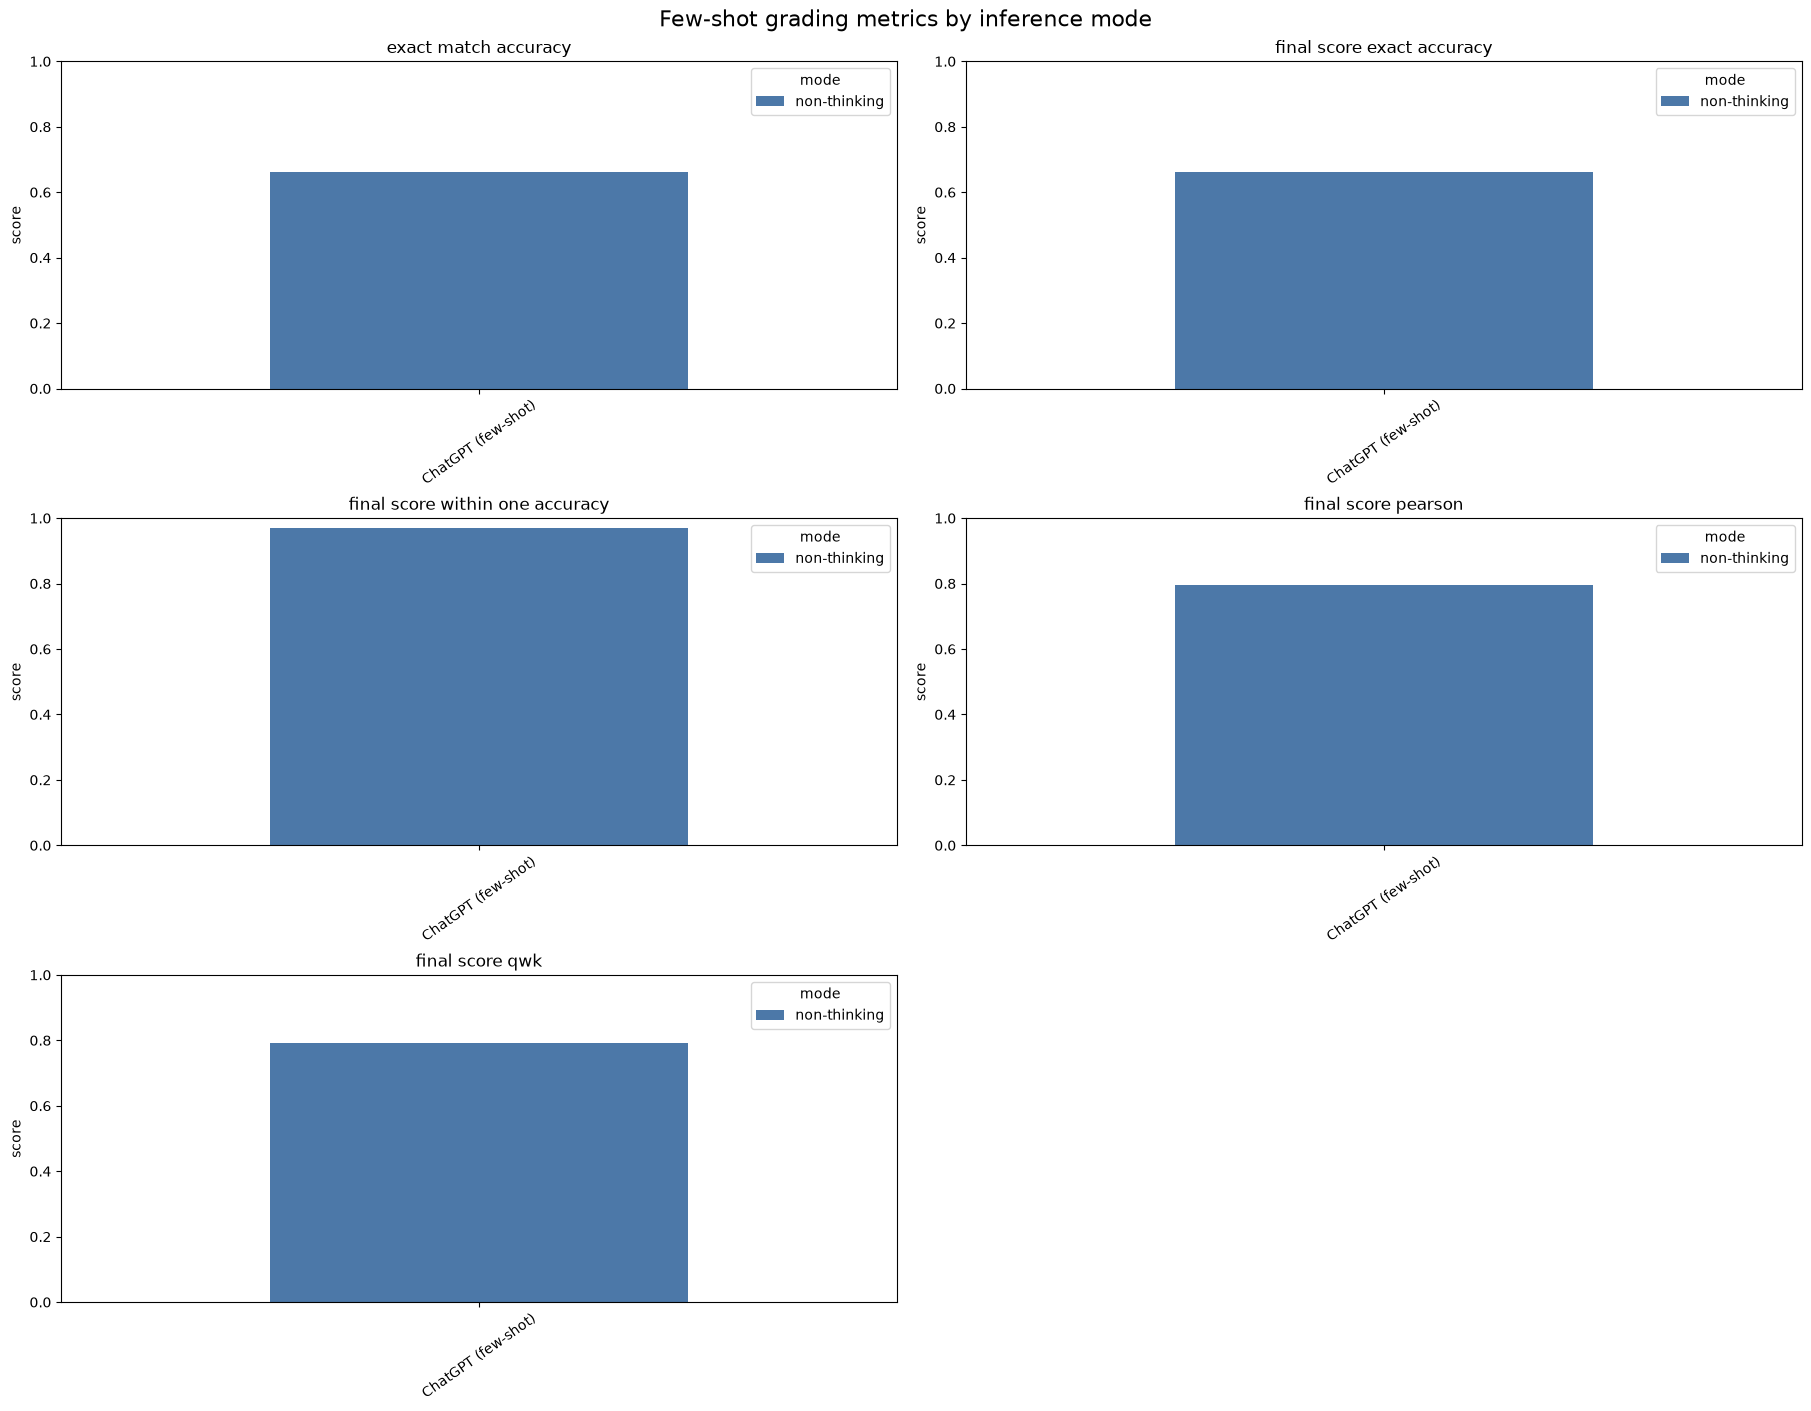

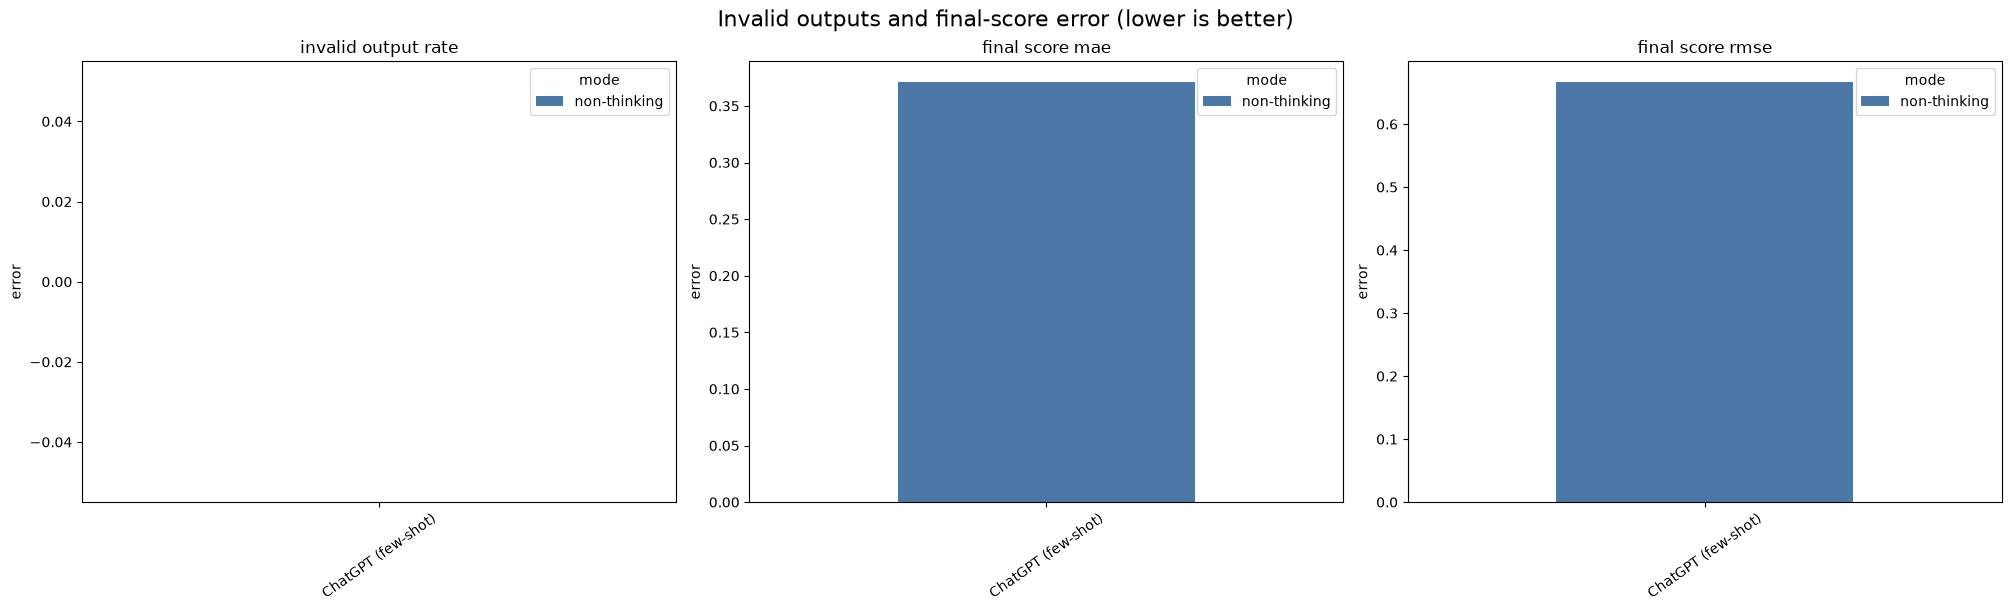

Thinking-delta graph skipped because thinking runs are disabled.


In [27]:
assert_all_runs_complete(summary_df)

accuracy_metrics = [
    "exact_match_accuracy",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_pearson",
    "final_score_qwk",
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14), constrained_layout=True)
for axis, metric in zip(axes.flat, accuracy_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")

for i in range(len(accuracy_metrics), len(axes.flat)):
    axes.flat[i].axis("off")

fig.suptitle("Few-shot grading metrics by inference mode", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__accuracy_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

error_metrics = ["invalid_output_rate", "final_score_mae", "final_score_rmse"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for axis, metric in zip(axes, error_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("error")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")
fig.suptitle("Invalid outputs and final-score error (lower is better)", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__error_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

available_modes = set(summary_df["mode"])
if {"non-thinking", "thinking"}.issubset(available_modes):
    delta_metrics = [
        "exact_match_accuracy", "final_score_exact_accuracy", "final_score_pearson", "final_score_qwk"
    ]
    delta_columns = []
    for metric in delta_metrics:
        pivot = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
        delta_columns.append((pivot["thinking"] - pivot["non-thinking"]).rename(metric))
    thinking_delta_df = pd.concat(delta_columns, axis=1)
    axis = thinking_delta_df.plot(kind="bar", figsize=(16, 7))
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title("Thinking-mode change relative to non-thinking")
    axis.set_ylabel("thinking minus non-thinking")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{RUN_TAG}__thinking_delta.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(thinking_delta_df.round(4))
else:
    print("Thinking-delta graph skipped because thinking runs are disabled.")